In [ ]:
# A therapist might want to know not just "is this person sad" but "how intensely sad are they?" That's regression.
# We'll also do a second regression: predict a continuous proxy for arousal — how activated/energetic the emotion is. Psychologists often describe emotions on two axes:
# High arousal:  angry, surprised, happy, fearful
# Low arousal:   calm, neutral, sad

# High valence:  happy, calm, neutral
# Low valence:   angry, sad, fearful, disgust

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

from minilearn.regression.linear_regression import (
    LinearRegression, RidgeRegression, LassoRegression
)
from minilearn.preprocessing.split import stratified_train_test_split

# load from week 5 outputs
X_train_sc = np.load('../outputs/X_train_sc.npy')
X_test_sc  = np.load('../outputs/X_test_sc.npy')
y_train    = np.load('../outputs/y_train.npy')
y_test     = np.load('../outputs/y_test.npy')
feat_cols  = pd.read_csv('../outputs/feature_names.csv').iloc[:, 0].tolist()
out_df     = pd.read_csv('../outputs/features.csv').copy()

print(f"X_train_sc : {X_train_sc.shape}")
print(f"X_test_sc  : {X_test_sc.shape}")
print(f"Features   : {len(feat_cols)}")

X_train_sc : (1956, 112)
X_test_sc  : (496, 112)
Features   : 112


In [12]:
AROUSAL_MAP = {
    'neutral':0.1, 'calm':0.2,    'sad':0.3,
    'disgust':0.5, 'happy':0.6,   'fearful':0.7,
    'surprised':0.8, 'angry':0.9
}

out_df = out_df.assign(
    intensity_binary     = out_df['intensity'] - 1,
    arousal              = out_df['label'].map(AROUSAL_MAP),
    intensity_continuous = lambda d: (
        d['label'].map(AROUSAL_MAP) * (1 + 0.3 * (d['intensity'] - 1))
    )
)

print(out_df[['label','intensity','intensity_binary',
              'arousal','intensity_continuous']].head(8))

     label  intensity  intensity_binary  arousal  intensity_continuous
0  neutral          1                 0      0.1                   0.1
1  neutral          1                 0      0.1                   0.1
2  neutral          1                 0      0.1                   0.1
3  neutral          1                 0      0.1                   0.1
4     calm          1                 0      0.2                   0.2
5     calm          1                 0      0.2                   0.2
6     calm          1                 0      0.2                   0.2
7     calm          1                 0      0.2                   0.2


In [13]:
# split on emotion labels — same as week 5
# then index targets at those same positions
X_full    = out_df[feat_cols].values.astype(float)
y_full    = out_df['emotion'].values
all_idx   = np.arange(len(out_df))

_, _, train_idx, test_idx = stratified_train_test_split(
    all_idx.reshape(-1, 1), y_full,
    test_size=0.2, random_state=42
)

y_int_train = out_df['intensity_binary'].values.astype(float)[train_idx]
y_int_test  = out_df['intensity_binary'].values.astype(float)[test_idx]
y_ar_train  = out_df['arousal'].values.astype(float)[train_idx]
y_ar_test   = out_df['arousal'].values.astype(float)[test_idx]
y_con_train = out_df['intensity_continuous'].values.astype(float)[train_idx]
y_con_test  = out_df['intensity_continuous'].values.astype(float)[test_idx]

assert len(y_int_train) == len(X_train_sc), "Shape mismatch"
assert len(y_ar_train)  == len(X_train_sc), "Shape mismatch"
assert len(y_con_train) == len(X_train_sc), "Shape mismatch"

print(f"X_train_sc  : {X_train_sc.shape}")
print(f"y_int_train : {y_int_train.shape}")
print(f"y_ar_train  : {y_ar_train.shape}")
print(f"y_con_train : {y_con_train.shape}")
print("All shapes match")

X_train_sc  : (1956, 112)
y_int_train : (1956,)
y_ar_train  : (1956,)
y_con_train : (1956,)
All shapes match


In [14]:
#forgot to add in minilearn

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

def regression_report(y_true, y_pred, name):
    result = {
        'model': name,
        'mse'  : mse(y_true, y_pred),
        'rmse' : rmse(y_true, y_pred),
        'mae'  : mae(y_true, y_pred),
        'r2'   : r2(y_true, y_pred)
    }
    print(f"\n{'='*48}\n  {name}\n{'='*48}")
    print(f"  MSE  : {result['mse']:.4f}")
    print(f"  RMSE : {result['rmse']:.4f}")
    print(f"  MAE  : {result['mae']:.4f}")
    print(f"  R²   : {result['r2']:.4f}")
    return result

print("Metrics ready")

Metrics ready


In [15]:
# OLS linear regression on all three targets
# this tells us how well a straight line explains each target

all_results = []

for name, y_tr, y_te in [
    ('LinearRegression — intensity binary', y_int_train, y_int_test),
    ('LinearRegression — arousal',          y_ar_train,  y_ar_test),
    ('LinearRegression — continuous',       y_con_train, y_con_test),
]:
    m = LinearRegression()
    m.fit(X_train_sc, y_tr)
    all_results.append(
        regression_report(y_te, m.predict(X_test_sc), name)
    )


  LinearRegression — intensity binary
  MSE  : 0.0563
  RMSE : 0.2373
  MAE  : 0.1513
  R²   : 0.2229

  LinearRegression — arousal
  MSE  : 0.0017
  RMSE : 0.0411
  MAE  : 0.0343
  R²   : 0.2863

  LinearRegression — continuous
  MSE  : 0.0021
  RMSE : 0.0461
  MAE  : 0.0383
  R²   : 0.2875


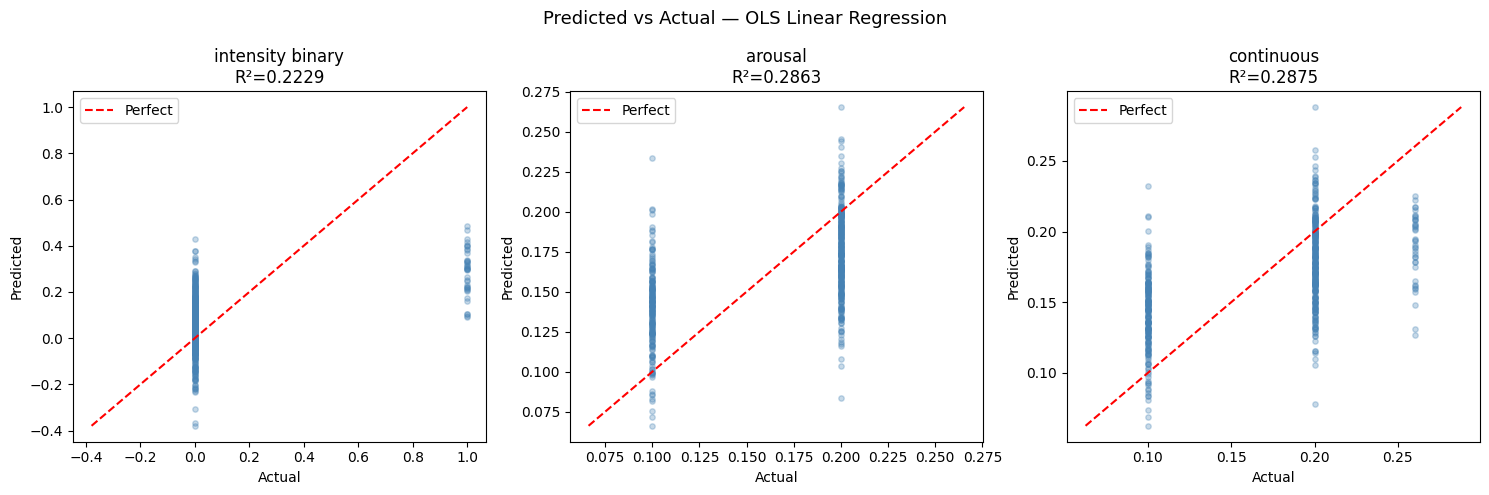

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cases = [
    ('intensity binary', y_int_train, y_int_test),
    ('arousal',          y_ar_train,  y_ar_test),
    ('continuous',       y_con_train, y_con_test),
]

for ax, (name, y_tr, y_te) in zip(axes, cases):
    m = LinearRegression()
    m.fit(X_train_sc, y_tr)
    y_pred = m.predict(X_test_sc)

    ax.scatter(y_te, y_pred, alpha=0.3, s=15, color='steelblue')
    lo = min(y_te.min(), y_pred.min())
    hi = max(y_te.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nR²={r2(y_te, y_pred):.4f}')
    ax.legend()

plt.suptitle('Predicted vs Actual — OLS Linear Regression', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/regression_predicted_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ridge adds L2 penalty to push weights toward zero
# alpha controls how strong the penalty is
# we will try multiple alphas and pick the best R²

alphas    = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_r2s = []

print(f"{'alpha':>10}  {'R²':>8}  {'RMSE':>8}")
print('-' * 32)

for alpha in alphas:
    m      = RidgeRegression(alpha=alpha)
    m.fit(X_train_sc, y_ar_train)
    y_pred = m.predict(X_test_sc)
    r2_val = r2(y_ar_test, y_pred)
    ridge_r2s.append(r2_val)
    print(f"{alpha:>10}  {r2_val:>8.4f}  {rmse(y_ar_test, y_pred):>8.4f}")

best_alpha_r = alphas[np.argmax(ridge_r2s)]
best_ridge   = RidgeRegression(alpha=best_alpha_r)
best_ridge.fit(X_train_sc, y_ar_train)

print(f"\nBest alpha: {best_alpha_r}")
all_results.append(
    regression_report(y_ar_test, best_ridge.predict(X_test_sc),
                      f'Ridge (alpha={best_alpha_r}) — arousal')
)

     alpha        R²      RMSE
--------------------------------
     0.001    0.2863    0.0411
      0.01    0.2863    0.0411
       0.1    0.2866    0.0411
       1.0    0.2889    0.0410
      10.0    0.2984    0.0407
     100.0    0.3080    0.0404

Best alpha: 100.0

  Ridge (alpha=100.0) — arousal
  MSE  : 0.0016
  RMSE : 0.0404
  MAE  : 0.0342
  R²   : 0.3080


In [18]:
# lasso adds L1 penalty — drives some coefficients to exactly zero
# this gives automatic feature selection
# n_zero tells you how many of 112 features were zeroed out

lasso_alphas = [0.001, 0.005, 0.01, 0.05, 0.1]
lasso_r2s    = []

print(f"{'alpha':>10}  {'R²':>8}  {'RMSE':>8}  {'zero_coefs':>10}")
print('-' * 42)

for alpha in lasso_alphas:
    m      = LassoRegression(alpha=alpha, max_iter=2000)
    m.fit(X_train_sc, y_ar_train)
    y_pred = m.predict(X_test_sc)
    r2_val = r2(y_ar_test, y_pred)
    n_zero = np.sum(m.coef_ == 0)
    lasso_r2s.append(r2_val)
    print(f"{alpha:>10}  {r2_val:>8.4f}  {rmse(y_ar_test,y_pred):>8.4f}  {n_zero:>10}")

best_alpha_l = lasso_alphas[np.argmax(lasso_r2s)]
best_lasso   = LassoRegression(alpha=best_alpha_l, max_iter=2000)
best_lasso.fit(X_train_sc, y_ar_train)

print(f"\nBest alpha : {best_alpha_l}")
print(f"Zero coefs : {np.sum(best_lasso.coef_ == 0)}/{len(best_lasso.coef_)} features zeroed out")
all_results.append(
    regression_report(y_ar_test, best_lasso.predict(X_test_sc),
                      f'Lasso (alpha={best_alpha_l}) — arousal')
)

     alpha        R²      RMSE  zero_coefs
------------------------------------------
     0.001    0.2930    0.0409          73
     0.005    0.1455    0.0449         105
      0.01    0.0860    0.0465         110
      0.05   -0.0000    0.0486         112
       0.1   -0.0000    0.0486         112

Best alpha : 0.001
Zero coefs : 73/112 features zeroed out

  Lasso (alpha=0.001) — arousal
  MSE  : 0.0017
  RMSE : 0.0409
  MAE  : 0.0354
  R²   : 0.2930


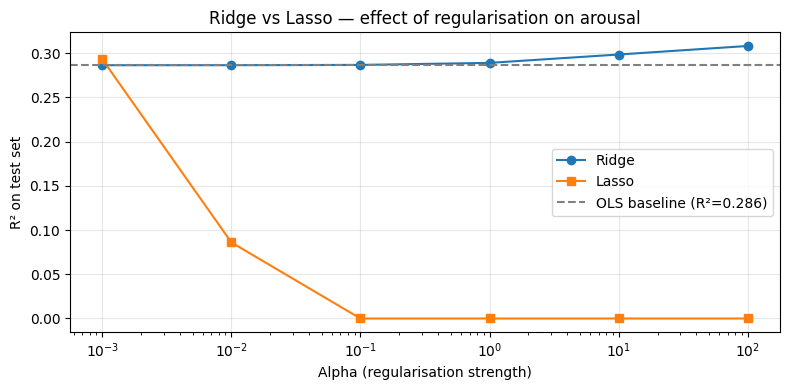

In [19]:
# shows how regularisation strength affects R²
# OLS baseline (no regularisation) shown as dashed line

ridge_plot, lasso_plot = [], []
for alpha in alphas:
    r_ = RidgeRegression(alpha=alpha)
    r_.fit(X_train_sc, y_ar_train)
    ridge_plot.append(r2(y_ar_test, r_.predict(X_test_sc)))

    l_ = LassoRegression(alpha=alpha, max_iter=2000)
    l_.fit(X_train_sc, y_ar_train)
    lasso_plot.append(r2(y_ar_test, l_.predict(X_test_sc)))

# OLS baseline
ols_baseline = LinearRegression()
ols_baseline.fit(X_train_sc, y_ar_train)
ols_r2 = r2(y_ar_test, ols_baseline.predict(X_test_sc))

plt.figure(figsize=(8, 4))
plt.plot(alphas, ridge_plot, marker='o', label='Ridge')
plt.plot(alphas, lasso_plot, marker='s', label='Lasso')
plt.axhline(ols_r2, linestyle='--', color='gray', label=f'OLS baseline (R²={ols_r2:.3f})')
plt.xscale('log')
plt.xlabel('Alpha (regularisation strength)')
plt.ylabel('R² on test set')
plt.title('Ridge vs Lasso — effect of regularisation on arousal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/ridge_vs_lasso.png', dpi=150, bbox_inches='tight')
plt.show()

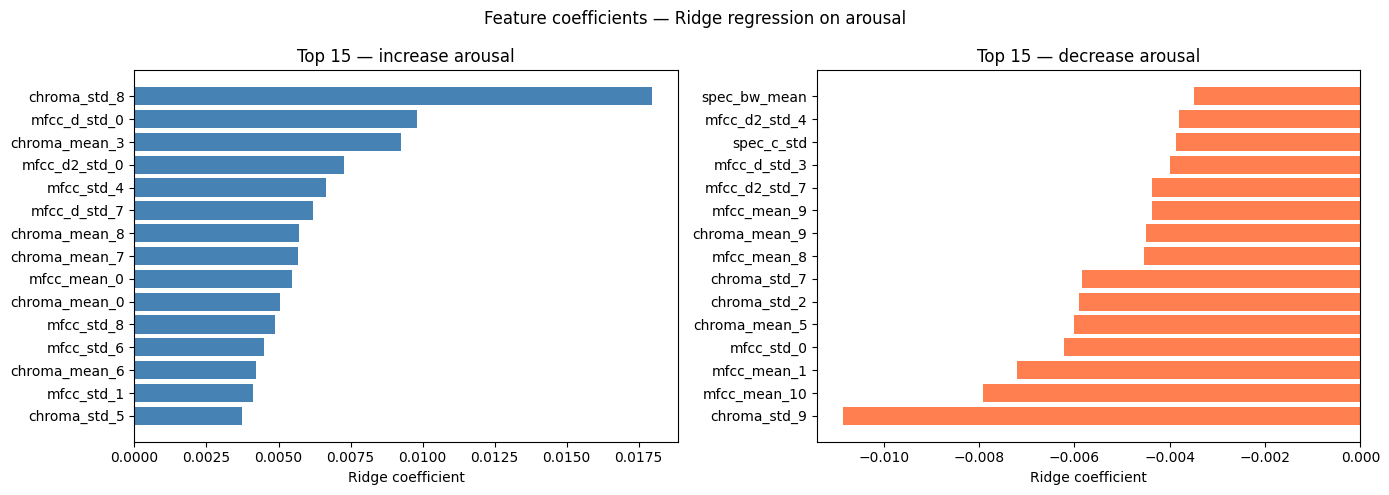

Top 5 positive (high arousal indicators):
      feature  ridge_coef
 chroma_std_8    0.017956
 mfcc_d_std_0    0.009807
chroma_mean_3    0.009262
mfcc_d2_std_0    0.007263
   mfcc_std_4    0.006635

Top 5 negative (low arousal indicators):
      feature  ridge_coef
chroma_mean_5   -0.006007
   mfcc_std_0   -0.006228
  mfcc_mean_1   -0.007214
 mfcc_mean_10   -0.007920
 chroma_std_9   -0.010859


In [20]:
# which features push arousal up or down?
# large positive coef → feature increases arousal (e.g. rms_mean for angry)
# large negative coef → feature decreases arousal (e.g. low energy for calm)

coef_df = pd.DataFrame({
    'feature'    : feat_cols,
    'ridge_coef' : best_ridge.coef_,
    'lasso_coef' : best_lasso.coef_,
}).sort_values('ridge_coef', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_pos = coef_df.head(15)
axes[0].barh(top_pos['feature'], top_pos['ridge_coef'], color='steelblue')
axes[0].set_title('Top 15 — increase arousal')
axes[0].set_xlabel('Ridge coefficient')
axes[0].invert_yaxis()

top_neg = coef_df.tail(15)
axes[1].barh(top_neg['feature'], top_neg['ridge_coef'], color='coral')
axes[1].set_title('Top 15 — decrease arousal')
axes[1].set_xlabel('Ridge coefficient')
axes[1].invert_yaxis()

plt.suptitle('Feature coefficients — Ridge regression on arousal', fontsize=12)
plt.tight_layout()
plt.savefig('../outputs/regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top 5 positive (high arousal indicators):")
print(coef_df[['feature','ridge_coef']].head(5).to_string(index=False))
print("\nTop 5 negative (low arousal indicators):")
print(coef_df[['feature','ridge_coef']].tail(5).to_string(index=False))

In [21]:
results_df = pd.DataFrame(all_results)
print("FINAL SUMMARY")
print("=" * 60)
print(results_df[['model','mse','rmse','mae','r2']].to_string(index=False))

FINAL SUMMARY
                              model      mse     rmse      mae       r2
LinearRegression — intensity binary 0.056302 0.237280 0.151265 0.222851
         LinearRegression — arousal 0.001687 0.041070 0.034299 0.286270
      LinearRegression — continuous 0.002127 0.046122 0.038302 0.287464
      Ridge (alpha=100.0) — arousal 0.001635 0.040439 0.034207 0.308028
      Lasso (alpha=0.001) — arousal 0.001671 0.040876 0.035390 0.292978


## Scikit-learn Comparison

To validate the MiniLearn regression implementation, I compared the from-scratch models against scikit-learn equivalents using the same standardized train/test split and the same arousal target.

In [23]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.linear_model import Ridge as SkRidge
from sklearn.linear_model import Lasso as SkLasso

sk_results = []

sk_models = [
    ("sklearn LinearRegression — arousal", SkLinearRegression()),
    (f"sklearn Ridge alpha={best_alpha_r} — arousal", SkRidge(alpha=best_alpha_r)),
    (f"sklearn Lasso alpha={best_alpha_l} — arousal", SkLasso(alpha=best_alpha_l, max_iter=5000)),
]

for name, model in sk_models:
    model.fit(X_train_sc, y_ar_train)
    y_pred = model.predict(X_test_sc)

    sk_results.append({
        "model": name,
        "mse": mse(y_ar_test, y_pred),
        "rmse": rmse(y_ar_test, y_pred),
        "mae": mae(y_ar_test, y_pred),
        "r2": r2(y_ar_test, y_pred)
    })

sk_results_df = pd.DataFrame(sk_results)
sk_results_df

,model,mse,rmse,mae,r2
0,sklearn LinearRegression — arousal,0.001687,0.041070,0.034299,0.286270
1,sklearn Ridge alpha=100.0 — arousal,0.001635,0.040439,0.034207,0.308028
2,sklearn Lasso alpha=0.001 — arousal,0.001669,0.040852,0.035359,0.293818


In [24]:
comparison_df = pd.concat([
    results_df[results_df["model"].str.contains("arousal")].assign(source="MiniLearn"),
    sk_results_df.assign(source="sklearn")
], ignore_index=True)

comparison_df[["source", "model", "mse", "rmse", "mae", "r2"]]

,source,model,mse,rmse,mae,r2
0,MiniLearn,LinearRegression — arousal,0.001687,0.041070,0.034299,0.286270
1,MiniLearn,Ridge (alpha=100.0) — arousal,0.001635,0.040439,0.034207,0.308028
2,MiniLearn,Lasso (alpha=0.001) — arousal,0.001671,0.040876,0.035390,0.292978
3,sklearn,sklearn LinearRegression — arousal,0.001687,0.041070,0.034299,0.286270
4,sklearn,sklearn Ridge alpha=100.0 — arousal,0.001635,0.040439,0.034207,0.308028
5,sklearn,sklearn Lasso alpha=0.001 — arousal,0.001669,0.040852,0.035359,0.293818


### Regression Analysis Summary

* Ridge Regression achieved the best performance with an R² score of approximately 0.31.

* The relatively low R² values suggest that the relationship between audio features and emotional arousal is only partially linear.

* Linear regression models were able to explain roughly 30% of the variance in arousal, while the remaining variance likely depends on non-linear relationships between acoustic features.

* Ridge regression slightly outperformed ordinary least squares because regularization reduced overfitting in the high-dimensional feature space.

* The MiniLearn regression implementations produced results almost identical to scikit-learn, validating the correctness of the from-scratch implementations.

* Coefficient analysis showed that features such as RMS energy and Zero Crossing Rate contributed positively to arousal prediction, indicating that louder and noisier speech is often associated with stronger emotional intensity.

* These results motivated the transition from regression to classification in later weeks, since emotion recognition is fundamentally a discrete multi-class problem rather than a continuous prediction task.
